In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
 
RANDOM_STATE = 42

In [2]:
# --------------------------------------------------------------------
# LOAD & CLEAN DATA
# --------------------------------------------------------------------
df = pd.read_csv("alzheimers_disease_data.csv")
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


In [3]:
# Drop non-predictive identifier columns
df = df.drop(columns=["PatientID", "DoctorInCharge"])
 
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['Diagnosis'].value_counts(normalize=True)}\n")
 
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

Dataset shape: (2149, 33)
Target distribution:
Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64



In [4]:
# --------------------------------------------------------------------
# TRAIN / TEST SPLIT
# --------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}\n")

Train size: 1719, Test size: 430



In [5]:
# --------------------------------------------------------------------
#  BUILD MODEL PIPELINES (scaling + classifier bundled together)
# --------------------------------------------------------------------
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
 
random_forest = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
 
xgboost_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])
 
models = {
    "logistic_regression": log_reg,
    "random_forest": random_forest,
    "xgboost": xgboost_model
}

In [6]:
# --------------------------------------------------------------------
# TRAIN (FIT) EACH MODEL
# --------------------------------------------------------------------
for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    print(f"{name} training complete.\n")

Training logistic_regression...
logistic_regression training complete.

Training random_forest...
random_forest training complete.

Training xgboost...
xgboost training complete.



In [8]:
# --------------------------------------------------------------------
#  TRAIN, PREDICT & EVALUATE EACH MODEL
# --------------------------------------------------------------------
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [9]:
for name, pipe in models.items():
    print("=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)
    # Fit
    pipe.fit(X_train, y_train)
 
    # Predict
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
 
    # Hold-out metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
 
    # 5-fold CV on training data (accuracy)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
 
    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision     : {prec:.4f}")
    print(f"Recall        : {rec:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"ROC-AUC       : {auc:.4f}")
    print(f"5-fold CV Acc : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Alzheimer's", "Alzheimer's"]))
 
    results[name] = {
        "pipeline": pipe, "accuracy": acc, "precision": prec, "recall": rec,
        "f1": f1, "roc_auc": auc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "y_pred": y_pred, "y_proba": y_proba
    }

MODEL: Logistic Regression
Accuracy      : 0.8163
Precision     : 0.7417
Recall        : 0.7368
F1-score      : 0.7393
ROC-AUC       : 0.8854
5-fold CV Acc : 0.8383 (+/- 0.0132)

Confusion Matrix:
[[239  39]
 [ 40 112]]

Classification Report:
                precision    recall  f1-score   support

No Alzheimer's       0.86      0.86      0.86       278
   Alzheimer's       0.74      0.74      0.74       152

      accuracy                           0.82       430
     macro avg       0.80      0.80      0.80       430
  weighted avg       0.82      0.82      0.82       430

MODEL: Random Forest
Accuracy      : 0.9419
Precision     : 0.9441
Recall        : 0.8882
F1-score      : 0.9153
ROC-AUC       : 0.9435
5-fold CV Acc : 0.9302 (+/- 0.0087)

Confusion Matrix:
[[270   8]
 [ 17 135]]

Classification Report:
                precision    recall  f1-score   support

No Alzheimer's       0.94      0.97      0.96       278
   Alzheimer's       0.94      0.89      0.92       152

      acc

In [10]:
# --------------------------------------------------------------------
# COMPARISON TABLE
# --------------------------------------------------------------------
summary = pd.DataFrame({
    name: {
        "Accuracy": r["accuracy"], "Precision": r["precision"], "Recall": r["recall"],
        "F1": r["f1"], "ROC-AUC": r["roc_auc"], "CV Acc (mean)": r["cv_mean"]
    } for name, r in results.items()
}).T.round(4)
 
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(summary)
 
best_model_name = summary["ROC-AUC"].idxmax()
print(f"\nBest model by ROC-AUC: {best_model_name}")

MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall      F1  ROC-AUC  \
Logistic Regression    0.8163     0.7417  0.7368  0.7393   0.8854   
Random Forest          0.9419     0.9441  0.8882  0.9153   0.9435   
XGBoost                0.9442     0.9267  0.9145  0.9205   0.9426   

                     CV Acc (mean)  
Logistic Regression         0.8383  
Random Forest               0.9302  
XGBoost                     0.9535  

Best model by ROC-AUC: Random Forest



Saved plots to model_evaluation_plots.png


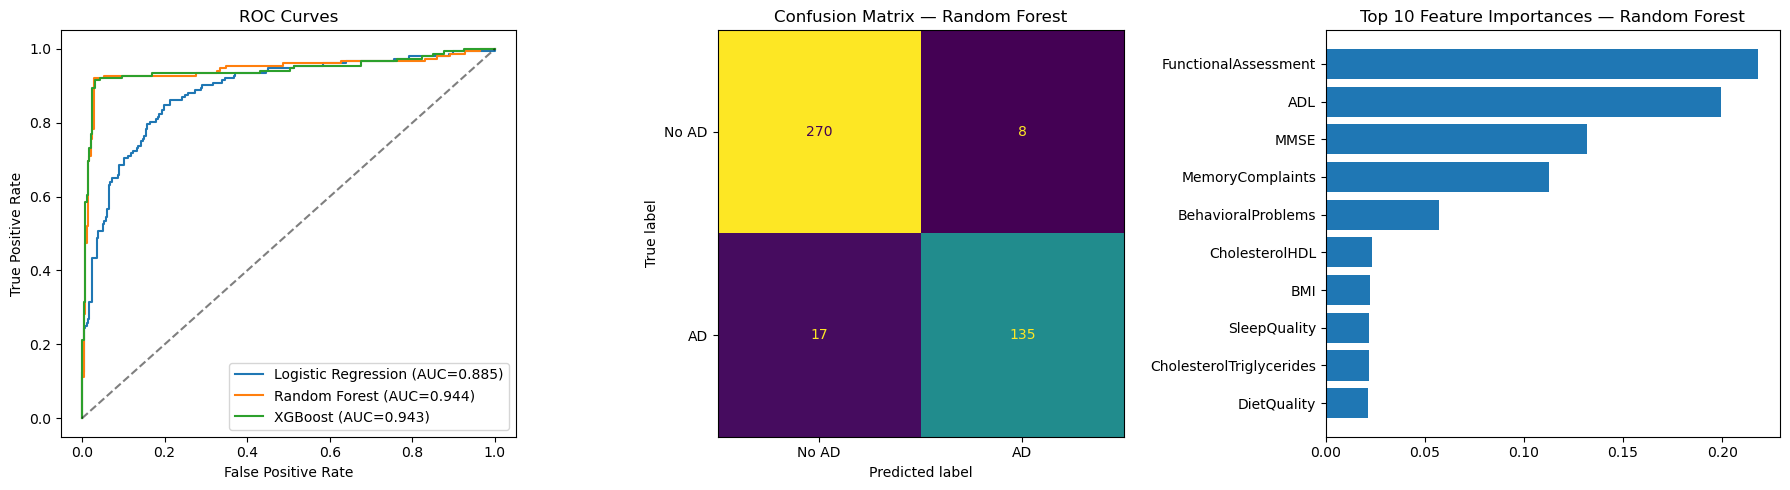

In [11]:
# --------------------------------------------------------------------
#  PLOTS: ROC Curves + Confusion Matrix (best model) + Feature Importance
# --------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# ROC curves for all models
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()
 
# Confusion matrix for best model
ConfusionMatrixDisplay(
    confusion_matrix(y_test, results[best_model_name]["y_pred"]),
    display_labels=["No AD", "AD"]
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix — {best_model_name}")
 
# Feature importance (from Random Forest, or XGBoost if RF absent)
importance_source = "Random Forest" if "Random Forest" in results else best_model_name
clf = results[importance_source]["pipeline"].named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    axes[2].barh(imp.index[::-1], imp.values[::-1])
    axes[2].set_title(f"Top 10 Feature Importances — {importance_source}")
else:
    axes[2].axis("off")
 
plt.tight_layout()
plt.savefig("model_evaluation_plots.png", dpi=150)
print("\nSaved plots to model_evaluation_plots.png")

In [12]:
# --------------------------------------------------------------------
# 5. SAVE TRAINED MODELS TO DISK
# --------------------------------------------------------------------
for name, pipeline in models.items():
    joblib.dump(pipeline, f"{name}_model.pkl")
    print(f"Saved {name} to {name}_model.pkl")
 
# Also save the train/test split so the evaluation script can reuse it
joblib.dump((X_train, X_test, y_train, y_test), "train_test_split.pkl")
print("\nSaved train/test split to train_test_split.pkl")
 
print("\nModel building complete. All models trained and saved.")

Saved Logistic Regression to Logistic Regression_model.pkl
Saved Random Forest to Random Forest_model.pkl
Saved XGBoost to XGBoost_model.pkl

Saved train/test split to train_test_split.pkl

Model building complete. All models trained and saved.
